<a href="https://colab.research.google.com/github/23aminaa/uk-phase3-cancer-trials-cost-analysis/blob/main/uk_phase3_cancer_trials_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import requests, numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss

# ---------- 1. Download the trials ----------
URL = "https://clinicaltrials.gov/api/v2/studies"
params = {
    "query.locn": "United Kingdom",
    "query.cond": "cancer",
    "filter.advanced": "AREA[Phase]PHASE3",
    "pageSize": 200,
}
rows, page = [], 0
while True:
    r = requests.get(URL, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()
    page += 1
    for s in data["studies"]:
        p = s.get("protocolSection", {})
        st = p.get("statusModule", {})
        des = p.get("designModule", {})
        di = des.get("designInfo", {})
        arms = p.get("armsInterventionsModule", {})
        sp = p.get("sponsorCollaboratorsModule", {})
        locs = p.get("contactsLocationsModule", {}).get("locations", [])
        rows.append({
            "nct_id": p.get("identificationModule", {}).get("nctId"),
            "status": st.get("overallStatus"),
            "start": st.get("startDateStruct", {}).get("date"),
            "sponsor_class": sp.get("leadSponsor", {}).get("class"),
            "allocation": di.get("allocation"),
            "masking": di.get("maskingInfo", {}).get("masking"),
            "n_arms": len(arms.get("armGroups", [])),
            "intervention_types": ",".join(sorted({i.get("type") for i in arms.get("interventions", []) if i.get("type")})),
            "conditions": "; ".join(p.get("conditionsModule", {}).get("conditions", [])),
            "n_countries": len({l.get("country") for l in locs if l.get("country")}),
            "n_uk_sites": sum(1 for l in locs if l.get("country") == "United Kingdom"),
        })
    print("page", page, "done,", len(rows), "trials so far")
    token = data.get("nextPageToken")
    if not token:
        break
    params["pageToken"] = token

# ---------- 2. Build the sample (2005 to 2019 starts) ----------
d3 = pd.DataFrame(rows)
d3["start"] = d3["start"].apply(lambda x: pd.to_datetime(x, errors="coerce"))
d3["label"] = d3["status"].map({"COMPLETED": 1, "TERMINATED": 0, "WITHDRAWN": 0})
d3["start_year"] = d3["start"].dt.year
m = d3.dropna(subset=["label", "start_year"])
m = m[(m["n_uk_sites"] > 0) & (m["start_year"] >= 2005) & (m["start_year"] <= 2019)].copy()
m.to_csv("uk_phase3_cancer_model_sample.csv", index=False)
print()
print("Model sample:", len(m), m["label"].value_counts().to_dict())

# ---------- 3. Model ----------
c = m["conditions"].str.lower().fillna("")
it = m["intervention_types"].fillna("")
X = pd.DataFrame({
    "industry": (m["sponsor_class"] == "INDUSTRY").astype(int),
    "randomised": (m["allocation"] == "RANDOMIZED").astype(int),
    "blinded": (m["masking"].notna() & (m["masking"] != "NONE")).astype(int),
    "three_plus_arms": (m["n_arms"] >= 3).astype(int),
    "biological": it.str.contains("BIOLOGICAL").astype(int),
    "log_countries": np.log1p(m["n_countries"]),
    "breast": c.str.contains("breast").astype(int),
    "lung": c.str.contains("lung").astype(int),
    "prostate": c.str.contains("prostate").astype(int),
    "colorectal": c.str.contains("colorectal|colon|rectal").astype(int),
    "blood_cancer": c.str.contains("leuk|lymphom|myelom").astype(int),
})
y = m["label"].astype(int)
train = m["start_year"] <= 2014
test = m["start_year"] >= 2015
print("train:", train.sum(), "test:", test.sum())

model = LogisticRegression(max_iter=1000, C=0.5).fit(X[train], y[train])
pr = model.predict_proba(X[test])[:, 1]
yt = y[test].values
base = y[train].mean()

print("AUC (0.5 = no skill):", round(roc_auc_score(yt, pr), 3))
print("Brier model:", round(brier_score_loss(yt, pr), 4))
print("Brier always-guess-average:", round(brier_score_loss(yt, np.full(len(yt), base)), 4))

rng = np.random.default_rng(0)
aucs = []
for _ in range(1000):
    i = rng.integers(0, len(yt), len(yt))
    if yt[i].min() != yt[i].max():
        aucs.append(roc_auc_score(yt[i], pr[i]))
print("AUC 95% range:", np.round(np.percentile(aucs, [2.5, 97.5]), 3))
print()
print(pd.Series(model.coef_[0], index=X.columns).round(2).sort_values())

page 1 done, 200 trials so far
page 2 done, 400 trials so far
page 3 done, 600 trials so far
page 4 done, 800 trials so far
page 5 done, 1000 trials so far
page 6 done, 1200 trials so far
page 7 done, 1400 trials so far
page 8 done, 1600 trials so far
page 9 done, 1800 trials so far
page 10 done, 1897 trials so far

Model sample: 852 {1.0: 684, 0.0: 168}
train: 563 test: 289
AUC (0.5 = no skill): 0.559
Brier model: 0.1637
Brier always-guess-average: 0.1648
AUC 95% range: [0.479 0.639]

industry          -0.73
lung              -0.19
randomised        -0.18
colorectal        -0.09
prostate          -0.08
blood_cancer       0.06
blinded            0.12
log_countries      0.28
three_plus_arms    0.35
biological         0.42
breast             0.77
dtype: float64


In [4]:
def wilson(k, n, z=1.96):
    if n == 0:
        return (float("nan"), float("nan"))
    p = k / n
    d = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / d
    half = z * ((p * (1 - p) / n + z**2 / (4 * n**2)) ** 0.5) / d
    return centre - half, centre + half

m["group"] = m["sponsor_class"].where(m["sponsor_class"].isin(["INDUSTRY", "OTHER", "NETWORK"]), "OTHER_GOV/NIH")
rows_out = []
for name, g in [("ALL", m)] + list(m.groupby("group")):
    k, n = int(g["label"].sum()), len(g)
    lo, hi = wilson(k, n)
    rows_out.append({"group": name, "trials": n, "completed": k,
                     "rate": round(k / n, 3), "low_95": round(lo, 3), "high_95": round(hi, 3)})
print(pd.DataFrame(rows_out).to_string(index=False))

        group  trials  completed  rate  low_95  high_95
          ALL     852        684 0.803   0.775    0.828
     INDUSTRY     745        596 0.800   0.770    0.827
      NETWORK      17          9 0.529   0.310    0.738
        OTHER      78         67 0.859   0.765    0.919
OTHER_GOV/NIH      12         12 1.000   0.757    1.000


In [5]:
import pandas as pd

# Completion rates from your real data: (central, low, high)
groups = {
    "All trials":     (0.803, 0.775, 0.828),
    "Industry":       (0.800, 0.770, 0.827),
    "Academic/other": (0.859, 0.765, 0.919),
}

# PLACEHOLDER cost assumptions. Replace with published benchmarks later.
planned_patients = 500
cost_per_patient = 30_000   # GBP per patient
setup_cost = 2_500_000      # GBP fixed set-up
stopped_fraction = 0.5      # share of full cost already spent when a trial stops

full_cost = planned_patients * cost_per_patient + setup_cost
print(f"Full cost if the trial completes: £{full_cost/1e6:.1f}m\n")

rows = []
for name, (p, lo, hi) in groups.items():
    for label, rate in [("low", lo), ("central", p), ("high", hi)]:
        expected = full_cost * (rate + (1 - rate) * stopped_fraction)
        per_completion = expected / rate
        rows.append({"group": name, "completion": label, "rate": rate,
                     "expected_cost_£m": round(expected / 1e6, 2),
                     "cost_per_completed_trial_£m": round(per_completion / 1e6, 2)})
print(pd.DataFrame(rows).to_string(index=False))

Full cost if the trial completes: £17.5m

         group completion  rate  expected_cost_£m  cost_per_completed_trial_£m
    All trials        low 0.775             15.53                        20.04
    All trials    central 0.803             15.78                        19.65
    All trials       high 0.828             15.99                        19.32
      Industry        low 0.770             15.49                        20.11
      Industry    central 0.800             15.75                        19.69
      Industry       high 0.827             15.99                        19.33
Academic/other        low 0.765             15.44                        20.19
Academic/other    central 0.859             16.27                        18.94
Academic/other       high 0.919             16.79                        18.27


In [6]:
import pandas as pd

rates = {"low 77.5%": 0.775, "central 80.3%": 0.803, "high 82.8%": 0.828}
fractions = [0.25, 0.50, 0.75]

table = {}
for fname in fractions:
    table[f"stopped at {int(fname*100)}% of cost"] = {
        label: f"{fname * (1 - p) / p * 100:.1f}%" for label, p in rates.items()
    }
print(pd.DataFrame(table).to_string())

              stopped at 25% of cost stopped at 50% of cost stopped at 75% of cost
low 77.5%                       7.3%                  14.5%                  21.8%
central 80.3%                   6.1%                  12.3%                  18.4%
high 82.8%                      5.2%                  10.4%                  15.6%


In [7]:
import requests, numpy as np, pandas as pd

URL = "https://clinicaltrials.gov/api/v2/studies"
params = {
    "query.locn": "United Kingdom",
    "query.cond": "cancer",
    "filter.advanced": "AREA[Phase]PHASE3",
    "pageSize": 200,
}
rows, page = [], 0
while True:
    r = requests.get(URL, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()
    page += 1
    for s in data["studies"]:
        p = s.get("protocolSection", {})
        st = p.get("statusModule", {})
        des = p.get("designModule", {})
        locs = p.get("contactsLocationsModule", {}).get("locations", [])
        rows.append({
            "status": st.get("overallStatus"),
            "start": st.get("startDateStruct", {}).get("date"),
            "end": st.get("completionDateStruct", {}).get("date"),
            "enrolment": des.get("enrollmentInfo", {}).get("count"),
            "n_uk_sites": sum(1 for l in locs if l.get("country") == "United Kingdom"),
        })
    print("page", page, "done,", len(rows), "trials so far")
    token = data.get("nextPageToken")
    if not token:
        break
    params["pageToken"] = token

d = pd.DataFrame(rows)
d["start"] = d["start"].apply(lambda x: pd.to_datetime(x, errors="coerce"))
d["end"] = d["end"].apply(lambda x: pd.to_datetime(x, errors="coerce"))
d["year"] = d["start"].dt.year
d = d[(d["n_uk_sites"] > 0) & d["year"].between(2005, 2019)]

comp = d[d["status"] == "COMPLETED"].dropna(subset=["enrolment"])
term = d[d["status"] == "TERMINATED"].dropna(subset=["enrolment"])
print()
print("completed with enrolment:", len(comp), "| terminated with enrolment:", len(term))
print("median enrolment, completed:", comp["enrolment"].median())
print("median enrolment, terminated:", term["enrolment"].median())

typical = comp["enrolment"].median()
ratio = (term["enrolment"] / typical).clip(upper=1)
print()
print("Terminated enrolment as share of a typical completed trial:")
print("  median:", round(ratio.median(), 2), "| mean:", round(ratio.mean(), 2))
print("  25th to 75th percentile:", np.round(ratio.quantile([0.25, 0.75]).values, 2))

for name, g in [("completed", comp), ("terminated", term)]:
    dur = ((g["end"] - g["start"]).dt.days / 30.44).dropna()
    print(name, "median duration (months):", round(dur.median(), 1), "from", len(dur), "trials")

page 1 done, 200 trials so far
page 2 done, 400 trials so far
page 3 done, 600 trials so far
page 4 done, 800 trials so far
page 5 done, 1000 trials so far
page 6 done, 1200 trials so far
page 7 done, 1400 trials so far
page 8 done, 1600 trials so far
page 9 done, 1800 trials so far
page 10 done, 1897 trials so far

completed with enrolment: 684 | terminated with enrolment: 162
median enrolment, completed: 538.0
median enrolment, terminated: 318.0

Terminated enrolment as share of a typical completed trial:
  median: 0.59 | mean: 0.59
  25th to 75th percentile: [0.2 1. ]
completed median duration (months): 70.6 from 675 trials
terminated median duration (months): 40.1 from 158 trials


In [8]:
import pandas as pd

full_cost = 17_500_000
setup, per_patient_total = 2_500_000, 15_000_000   # placeholder split of the £17.5m
rates = {"low 77.5%": 0.775, "central 80.3%": 0.803, "high 82.8%": 0.828}
patient_share = {"low (0.20)": 0.20, "central (0.59)": 0.59, "high (1.00)": 1.00}

rows = []
for rname, p in rates.items():
    for sname, f in patient_share.items():
        stopped_cost = setup + f * per_patient_total          # set-up is sunk
        expected = p * full_cost + (1 - p) * stopped_cost
        rows.append({"completion": rname, "patient share spent": sname,
                     "cost per completed trial £m": round(expected / p / 1e6, 1),
                     "premium vs full cost": f"{(expected / p / full_cost - 1) * 100:.0f}%"})
print(pd.DataFrame(rows).to_string(index=False))

   completion patient share spent  cost per completed trial £m premium vs full cost
    low 77.5%          low (0.20)                         19.1                   9%
    low 77.5%      central (0.59)                         20.8                  19%
    low 77.5%         high (1.00)                         22.6                  29%
central 80.3%          low (0.20)                         18.8                   8%
central 80.3%      central (0.59)                         20.3                  16%
central 80.3%         high (1.00)                         21.8                  25%
   high 82.8%          low (0.20)                         18.6                   7%
   high 82.8%      central (0.59)                         19.9                  13%
   high 82.8%         high (1.00)                         21.1                  21%


In [10]:
from google.colab import files
files.download('my_data.csv')


FileNotFoundError: Cannot find file: my_data.csv

In [11]:
!ls


sample_data  uk_phase3_cancer_model_sample.csv


In [13]:
import pandas as pd

# Load your data
df = pd.read_csv('uk_phase3_cancer_model_sample.csv')

# Display as an interactive, searchable grid
df


,nct_id,status,start,sponsor_class,allocation,masking,n_arms,intervention_types,conditions,n_countries,n_uk_sites,label,start_year
0,NCT03016312,COMPLETED,2017-01-10,INDUSTRY,RANDOMIZED,NONE,2,DRUG,"Prostatic Neoplasms, Castration-Resistant",21,6,1.0,2017.0
1,NCT03434379,COMPLETED,2018-03-15,INDUSTRY,RANDOMIZED,NONE,2,DRUG,"Carcinoma, Hepatocellular",17,4,1.0,2018.0
2,NCT00484939,COMPLETED,2007-07-01,INDUSTRY,RANDOMIZED,NONE,2,DRUG,Colorectal Cancer,12,9,1.0,2007.0
3,NCT00263822,COMPLETED,2005-09-01,NETWORK,RANDOMIZED,NONE,0,DRUG,Fallopian Tube Cancer; Ovarian Cancer; Primary...,8,25,1.0,2005.0
4,NCT01618370,COMPLETED,2012-07-22,INDUSTRY,NaN,NONE,1,DRUG,Prostatic Neoplasms,19,27,1.0,2012.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
847,NCT00876395,COMPLETED,2009-09-10,INDUSTRY,RANDOMIZED,QUADRUPLE,2,DRUG,Breast Cancer,28,3,1.0,2009.0
848,NCT01901146,COMPLETED,2013-04-29,INDUSTRY,RANDOMIZED,QUADRUPLE,2,"DRUG,PROCEDURE",Breast Cancer,18,2,1.0,2013.0
849,NCT03734029,COMPLETED,2018-12-27,INDUSTRY,RANDOMIZED,NONE,2,DRUG,Breast Cancer,20,7,1.0,2018.0
850,NCT00389870,COMPLETED,2006-12-01,OTHER,RANDOMIZED,NONE,0,"BIOLOGICAL,DRUG",Colorectal Cancer,1,33,1.0,2006.0


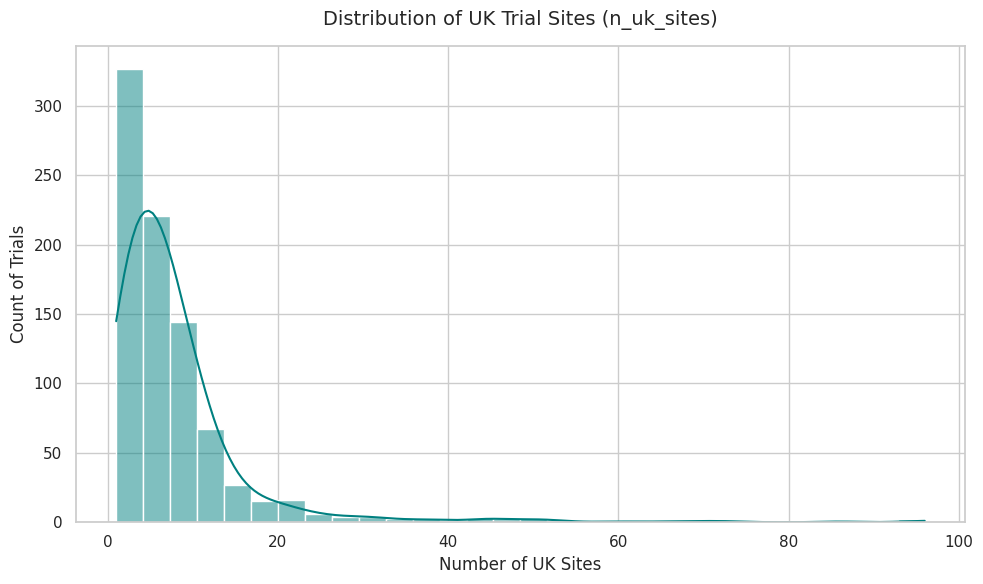

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style of the plots
sns.set_theme(style="whitegrid")

# Create a figure
fig = plt.figure(figsize=(10, 6))

# Plot the histogram of 'n_uk_sites'
sns.histplot(data=df, x='n_uk_sites', bins=30, kde=True, color='teal')

# Add descriptive titles and labels
plt.title('Distribution of UK Trial Sites (n_uk_sites)', fontsize=14, pad=15)
plt.xlabel('Number of UK Sites', fontsize=12)
plt.ylabel('Count of Trials', fontsize=12)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [15]:
!pip install -q gradio pandas plotly

import gradio as gr
import pandas as pd
import plotly.express as px

# 1. Load the data
df = pd.read_csv('uk_phase3_cancer_model_sample.csv')

# 2. Define dashboard functions
def get_data_summary():
    # Returns basic stats and shape of your data
    return f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns."

def plot_interactive_chart(column_name):
    # Dynamically generates a chart based on the column chosen
    if df[column_name].dtype == 'object' or df[column_name].nunique() < 15:
        fig = px.histogram(df, x=column_name, title=f"Distribution of {column_name}", template="plotly_white")
    else:
        fig = px.box(df, y=column_name, title=f"Spread of {column_name}", template="plotly_white")
    return fig

# 3. Build the Layout Grid
with gr.Blocks(theme=gr.themes.Soft()) as dashboard:
    gr.Markdown("# 📊 UK Phase 3 Cancer Model Insights")

    with gr.Row():
        text_output = gr.Textbox(label="Dataset Overview", value=get_data_summary(), interactive=False)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### Dashboard Controls")
            # Automatically populates a dropdown with your CSV columns
            column_dropdown = gr.Dropdown(choices=list(df.columns), value=list(df.columns)[0], label="Select Feature to Analyze")
            submit_btn = gr.Button("Update Chart", variant="primary")

        with gr.Column(scale=3):
            plot_output = gr.Plot(label="Interactive Visualization")

    # Link the button to update the chart dynamically
    submit_btn.click(fn=plot_interactive_chart, inputs=column_dropdown, outputs=plot_output)
    dashboard.load(fn=plot_interactive_chart, inputs=column_dropdown, outputs=plot_output)

# 4. Launch it inside Colab
dashboard.launch(inline=True=True, show_error=True)


SyntaxError: invalid syntax (2752234913.py, line 45)

In [16]:
!pip install -q gradio pandas plotly

import gradio as gr
import pandas as pd
import plotly.express as px

# 1. Load the data
df = pd.read_csv('uk_phase3_cancer_model_sample.csv')

# 2. Define dashboard functions
def get_data_summary():
    return f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns."

def plot_interactive_chart(column_name):
    if df[column_name].dtype == 'object' or df[column_name].nunique() < 15:
        fig = px.histogram(df, x=column_name, title=f"Distribution of {column_name}", template="plotly_white")
    else:
        fig = px.box(df, y=column_name, title=f"Spread of {column_name}", template="plotly_white")
    return fig

# 3. Build the Layout Grid
with gr.Blocks(theme=gr.themes.Soft()) as dashboard:
    gr.Markdown("# 📊 UK Phase 3 Cancer Model Insights")

    with gr.Row():
        text_output = gr.Textbox(label="Dataset Overview", value=get_data_summary(), interactive=False)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### Dashboard Controls")
            column_dropdown = gr.Dropdown(choices=list(df.columns), value=list(df.columns)[0], label="Select Feature to Analyze")
            submit_btn = gr.Button("Update Chart", variant="primary")

        with gr.Column(scale=3):
            plot_output = gr.Plot(label="Interactive Visualization")

    # Link the button to update the chart dynamically
    submit_btn.click(fn=plot_interactive_chart, inputs=column_dropdown, outputs=plot_output)
    dashboard.load(fn=plot_interactive_chart, inputs=column_dropdown, outputs=plot_output)

# 4. Launch it inside Colab (Fixed syntax here)
dashboard.launch(inline=True, show_error=True)


/tmp/ipykernel_1462/2887219995.py:22: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as dashboard:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c615447c693f3f060a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
